In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("multimodal_test_public.tsv", sep="\t")
df.head()

,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,subreddit,title,upvote_ratio,2_way_label,3_way_label,6_way_label
0,trustbytrust,stargazer,1.425139e+09,NaN,True,cozywbv,http://i.imgur.com/BruWKDi.jpg,2xct9d,NaN,3,psbattle_artwork,stargazer,NaN,0,2,4
1,NaN,yeah,1.438173e+09,NaN,True,ctk61yw,http://i.imgur.com/JRZT727.jpg,3f0h7o,NaN,2,psbattle_artwork,yeah,NaN,0,2,4
2,chaseoes,pd phoenix car thief gets instructions from yo...,1.560492e+09,abc15.com,True,c0gl7r,https://external-preview.redd.it/1A2_4VwgS8Qd2...,NaN,2.0,16,nottheonion,PD: Phoenix car thief gets instructions from Y...,0.89,1,0,0
3,SFepicure,as trump accuses iran he has one problem his o...,1.560606e+09,nytimes.com,True,c0xdqy,https://external-preview.redd.it/9BKRcgvaobpTo...,NaN,4.0,45,neutralnews,"As Trump Accuses Iran, He Has One Problem: His...",0.78,1,0,0
4,fragments_from_Work,believers hezbollah,1.515139e+09,i.imgur.com,True,7o9rmx,https://external-preview.redd.it/rbwXHncnjVh51...,NaN,40.0,285,propagandaposters,"""Believers"" - Hezbollah 2011",0.95,0,1,5


In [6]:
df.columns

Index(['author', 'clean_title', 'created_utc', 'domain', 'hasImage', 'id',
       'image_url', 'linked_submission_id', 'num_comments', 'score',
       'subreddit', 'title', 'upvote_ratio', '2_way_label', '3_way_label',
       '6_way_label'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59319 entries, 0 to 59318
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   author                56251 non-null  object 
 1   clean_title           59319 non-null  object 
 2   created_utc           59319 non-null  float64
 3   domain                41847 non-null  object 
 4   hasImage              59319 non-null  bool   
 5   id                    59319 non-null  object 
 6   image_url             59163 non-null  object 
 7   linked_submission_id  17472 non-null  object 
 8   num_comments          41847 non-null  float64
 9   score                 59319 non-null  int64  
 10  subreddit             59319 non-null  object 
 11  title                 59319 non-null  object 
 12  upvote_ratio          41847 non-null  float64
 13  2_way_label           59319 non-null  int64  
 14  3_way_label           59319 non-null  int64  
 15  6_way_label        

In [8]:
df.isnull().sum()

author                   3068
clean_title                 0
created_utc                 0
domain                  17472
hasImage                    0
id                          0
image_url                 156
linked_submission_id    41847
num_comments            17472
score                       0
subreddit                   0
title                       0
upvote_ratio            17472
2_way_label                 0
3_way_label                 0
6_way_label                 0
dtype: int64

In [9]:
df["2_way_label"].value_counts()

2_way_label
0    35812
1    23507
Name: count, dtype: int64

In [4]:
import os

image_folder = "images"   # Replace with your image folder

files = os.listdir(image_folder)

print("Total images:", len(files))
print(files[:20])      # Show the first 20 filenames

Total images: 39143
['100n2e.jpg', '100rzy.jpg', '10150o.jpg', '102ahb.jpg', '102r5n.jpg', '103yff.jpg', '1051z5.jpg', '106b7q.jpg', '106qrz.jpg', '106yw5.jpg', '107mbp.jpg', '107pmk.jpg', '107s8z.jpg', '107xdb.jpg', '1084cu.jpg', '1085it.jpg', '10999x.jpg', '109tze.jpg', '10a5di.jpg', '10a76s.jpg']


In [5]:
df["id"].head(20)

0     cozywbv
1     ctk61yw
2      c0gl7r
3      c0xdqy
4      7o9rmx
5      bdfxf1
6      8g3xtm
7      26kwdf
8      2s0xuj
9     cbyjnry
10     bopb6s
11     64b266
12     7iqceh
13     5rhizs
14     3gzxbc
15     c82k3s
16     1epbxk
17     b36dy1
18     53b5b5
19     541v7x
Name: id, dtype: object

In [6]:
sample_names = [f.split(".")[0] for f in files[:20]]

df[df["id"].isin(sample_names)][["id"]]

,id
615,102ahb
7671,107pmk
9606,1051z5
11499,109tze
16902,1085it
17075,103yff
17358,100n2e
18829,106qrz
19262,10150o
24721,10a76s


In [7]:
import os

image_folder = "images"

df["image_path"] = df["id"].apply(
    lambda x: os.path.join(image_folder, f"{x}.jpg")
)

In [8]:
df["image_exists"] = df["image_path"].apply(os.path.exists)

df["image_exists"].value_counts()

image_exists
True     39143
False    20176
Name: count, dtype: int64

In [9]:
df = df[df["image_exists"]].reset_index(drop=True)

Title : pd phoenix car thief gets instructions from youtube video
Label : 1


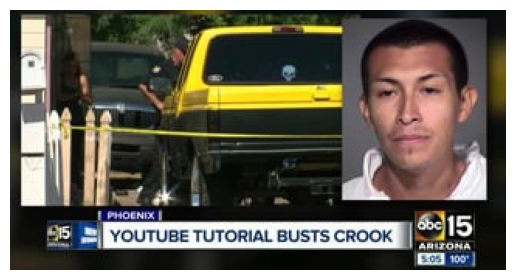

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

sample = df.iloc[0]

img = Image.open(sample["image_path"])

plt.imshow(img)
plt.axis("off")

print("Title :", sample["clean_title"])
print("Label :", sample["2_way_label"])

In [11]:
print("Total samples:", len(df))

Total samples: 39143


In [12]:
df["2_way_label"].value_counts()

2_way_label
1    21740
0    17403
Name: count, dtype: int64

In [13]:
sample = df.sample(1).iloc[0]

print("ID:", sample["id"])
print("Title:", sample["clean_title"])
print("Label:", sample["2_way_label"])
print("Image Path:", sample["image_path"])

ID: 2cxsl6
Title: my coworker the super villain
Label: 1
Image Path: images\2cxsl6.jpg


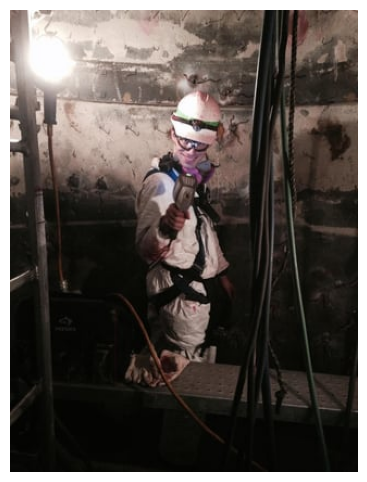

In [14]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(sample["image_path"])

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [15]:
from PIL import Image

bad_images = []

for path in df["image_path"]:
    try:
        img = Image.open(path)
        img.verify()
    except:
        bad_images.append(path)

print("Corrupted images:", len(bad_images))

Corrupted images: 30


In [16]:
# Get only the file paths
bad_paths = [item[0] for item in bad_images]

# Remove rows with corrupted images
df = df[~df["image_path"].isin(bad_paths)].reset_index(drop=True)

print("Remaining samples:", len(df))

Remaining samples: 39143


In [17]:
print(df.shape)

(39143, 18)


In [18]:
df.to_csv("fakeddit_cleaned.csv", index=False)